Author: Krish

In [1]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from datetime import date

In [2]:
data_path = "C:\\Users\\akl0407\\OneDrive - Northwestern University\\Back up\\2025-26\\Spring 2025\\STAT390\\LegalAid\\Data\\CAR_-_EP_Flow_Activity_Queue__Agent_Names\\"
adhoc_data_path = 'C:\\Users\\akl0407\\OneDrive - Northwestern University\\Back up\\2025-26\\Fall 2025\\LegalAid\\Adhoc\\Adhoc datasets\\'

In [3]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


In [ ]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

In [ ]:
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y/%m/%d %I:%M:%S %p"))

In [ ]:
df_main.shape

In [ ]:
df_main.dtypes

In [ ]:
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour

In [ ]:
df_main.sort_values(by = ['Contact Session ID', 'Activity Start Timestamp'], inplace=True)

In [ ]:
df_main.reset_index(inplace = True, drop = True)

In [ ]:
df_main.head()

# Jake's dashboard

In [15]:
def custdata(id):
    return df_main.loc[df_main['Contact Session ID'] == id,:]
def act_rows(act):
    return df_main.loc[df_main['Activity Name'] == act,:]
def act_data(act):
    get_act_rows = act_rows(act)
    return df_main.loc[df_main['Contact Session ID'].isin(get_act_rows['Contact Session ID']),:]
def data_rows(act, data):
    return data.loc[data['Activity Name'] == act,:]
def col_data(col, val):
    get_col_rows = df_main.loc[df_main[col] == val,:]
    return df_main.loc[df_main['Contact Session ID'].isin(get_col_rows['Contact Session ID']),:]
def col_rows(col, val):
    return df_main.loc[df_main[col] == val,:]

### 30 Nov

In [17]:
act_rows('FamilyMenu')['Contact Session ID'].nunique()

24794

## 24th Nov

In [14]:
lang_rows = df_main.loc[df_main['Activity Name'] == 'LanguageSelectionMenu',:]
non_lang_data = df_main.loc[~df_main['Contact Session ID'].isin(lang_rows['Contact Session ID']),:]
non_lang_data['EP Name'].value_counts()

EP Name
Intake Outdial EP                           65456
Pre-Legal Menu Seniors Menu Telephony EP    29178
Legal Menu Telephony EP                     22343
Closed Queue Menu Telephony EP              13919
Main Number Telephony EP                     9325
All LAC Queues Telephony EP                  7913
Courtesy Callback Telephony EP               7410
Other Legal Menu Telephony EP                4560
Legal Housing Menu Telephony EP              4000
Legal Family Menu Telephony EP               2932
Legal Benefits Menu Telephony EP             1248
Legal Immigration Menu Telephony EP          1148
Legal HIV Menu Telephony EP                   815
Legal Employment Menu Telephony EP            453
Closed Hours-Holidays Menu Telephony EP        27
Farmworker Main Number Telephony EP             1
Name: count, dtype: int64

In [16]:
first_EP = non_lang_data.groupby('Contact Session ID').first()

In [18]:
first_EP['EP Name'].value_counts()

EP Name
Intake Outdial EP                      9395
Main Number Telephony EP               9157
Farmworker Main Number Telephony EP       1
Name: count, dtype: int64

In [50]:
intake_outdial_rows = first_EP.loc[first_EP['EP Name'] == 'Intake Outdial EP',:]
intake_outdial_data = df_main.loc[df_main['Contact Session ID'].isin(intake_outdial_rows.index),:]
intake_outdial_data['Activity Name'].value_counts()

Activity Name
SetCallerID          18734
DisconnectContact     9390
Name: count, dtype: int64

In [63]:
custdata(intake_outdial_data['Contact Session ID'].unique()[8230])

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour
2903217,df4bcb01-a9d0-4ba6-b1e4-2bbf24700257,Intake Outdial EP,NaN,NaN,2025-09-02 11:56:52,NaN,NaN,NaN,11
2903218,df4bcb01-a9d0-4ba6-b1e4-2bbf24700257,NaN,Intake_Outdial,NaN,2025-09-02 11:56:52,NaN,NaN,NaN,11
2903219,df4bcb01-a9d0-4ba6-b1e4-2bbf24700257,Intake Outdial EP,NaN,DisconnectContact,2025-09-02 11:56:52,NaN,NaN,NaN,11
2903220,df4bcb01-a9d0-4ba6-b1e4-2bbf24700257,Intake Outdial EP,NaN,SetCallerID,2025-09-02 11:56:53,NaN,NaN,NaN,11
2903221,df4bcb01-a9d0-4ba6-b1e4-2bbf24700257,Intake Outdial EP,NaN,SetCallerID,2025-09-02 11:56:53,NaN,NaN,NaN,11
2903222,df4bcb01-a9d0-4ba6-b1e4-2bbf24700257,Intake Outdial EP,NaN,NaN,2025-09-02 11:56:53,Intake Outdial Queue,Ana Franco,NaN,11
2903223,df4bcb01-a9d0-4ba6-b1e4-2bbf24700257,Intake Outdial EP,NaN,NaN,2025-09-02 11:57:17,Intake Outdial Queue,Ana Franco,NaN,11
2903224,df4bcb01-a9d0-4ba6-b1e4-2bbf24700257,NaN,NaN,NaN,2025-09-02 12:01:11,Intake Outdial Queue,Ana Franco,NaN,12
2903225,df4bcb01-a9d0-4ba6-b1e4-2bbf24700257,Intake Outdial EP,NaN,NaN,2025-09-02 12:01:11,Intake Outdial Queue,NaN,Agent Left,12
2903226,df4bcb01-a9d0-4ba6-b1e4-2bbf24700257,NaN,NaN,NaN,2025-09-02 12:01:52,Intake Outdial Queue,Ana Franco,NaN,12


In [20]:
chck = first_EP.loc[first_EP['EP Name'] == 'Main Number Telephony EP',:]
chck

,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour
Contact Session ID,,,,,,,,
000518a4-b67b-4de8-914c-2c300b15ba75,Main Number Telephony EP,LACMain,SeniorsMenu,2025-08-05 10:55:57,None,None,Customer Left,10
001d8080-ee77-4689-8e0a-db79c88148b5,Main Number Telephony EP,LACMain,SeniorsMenu,2024-09-09 16:19:50,Front Desk Transfer,CBT Agent,None,16
0024ac55-5dc3-44ba-b5f0-9f6ad993c4c8,Main Number Telephony EP,LACMain,SeniorsMenu,2025-08-20 12:57:17,Clinic Voicemail Transfer,CBT Agent,Customer Left,12
00252732-cf29-493b-88c5-cf92f24ddcd6,Main Number Telephony EP,LACMain,SeniorsMenu,2024-09-13 13:35:07,Front Desk Transfer,CBT Agent,None,13
0033f359-9014-4c19-bf31-9799518a9950,Main Number Telephony EP,LACMain,SeniorsMenu,2024-11-01 13:25:42,Clinic Voicemail Transfer,CBT Agent,None,13
...,...,...,...,...,...,...,...,...
ffeb296c-7944-4ddf-aefa-6432f4d2e182,Main Number Telephony EP,LACMain,SeniorsMenu,2025-05-29 13:37:06,None,None,Customer Left,13
ffede47d-2f46-4cf4-9355-13a36a4c4dbb,Main Number Telephony EP,LACMain,SeniorsMenu,2024-10-22 13:27:05,Clinic Voicemail Transfer,CBT Agent,None,13
ffeed6a2-679d-4597-a261-a20423e66083,Main Number Telephony EP,LACMain,SeniorsMenu,2024-08-22 11:39:20,Front Desk Transfer,CBT Agent,None,11


In [26]:
chck_preleg = df_main.loc[df_main['Contact Session ID'].isin(chck.index),:]

In [28]:
chck_preleg['Contact Session ID'].nunique()

9157

In [ ]:
chck

In [110]:

lang_rows = df_main.loc[df_main['Activity Name'] == 'LanguageSelectionMenu',:]
non_lang_data = df_main.loc[~df_main['Contact Session ID'].isin(lang_rows['Contact Session ID']),:]
first_EP = non_lang_data.groupby('Contact Session ID').first()
non_lang_main_menu = first_EP.loc[first_EP['EP Name'] == 'Main Number Telephony EP',:]
non_lang_main_menu_data = df_main.loc[df_main['Contact Session ID'].isin(non_lang_main_menu.index),:]
non_lang_main_menu_data['Contact Session ID'].nunique()
#chck_preleg_rows = chck_preleg.loc[chck_preleg['EP Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP',:]
#chck_preleg_data = df_main.loc[df_main['Contact Session ID'].isin(chck_preleg_rows['Contact Session ID']),:]
#chck_preleg_data['Contact Session ID'].nunique()

9157

In [ ]:
chck_preleg_rows = chck_preleg.loc[chck_preleg['EP Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP',:]
chck_preleg_data = df_main.loc[df_main['Contact Session ID'].isin(chck_preleg_rows['Contact Session ID']),:]
chck_preleg_data['Contact Session ID'].nunique()

In [35]:
chck2 = df_main.loc[(df_main['Contact Session ID'].isin(chck_preleg['Contact Session ID'])) & \
(~df_main['Contact Session ID'].isin(chck_preleg_data['Contact Session ID'])),:]

In [36]:
chck2['Contact Session ID'].nunique()

166

In [37]:
166+ 8991

9157

In [112]:
farmworker_rows = df_main.loc[df_main['Activity Name'] == 'FarmworkerMainMenu',:]
custdata(farmworker_rows['Contact Session ID'].unique()[0])

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour
121,0003aec2-1d09-47d3-8d08-937b92764eee,Farmworker Main Number Telephony EP,NaN,NaN,2024-05-24 13:43:04,NaN,NaN,NaN,13
122,0003aec2-1d09-47d3-8d08-937b92764eee,NaN,FarmworkerMain,NaN,2024-05-24 13:43:04,NaN,NaN,NaN,13
123,0003aec2-1d09-47d3-8d08-937b92764eee,Farmworker Main Number Telephony EP,NaN,LanguageSelectionMenu,2024-05-24 13:43:04,NaN,NaN,NaN,13
124,0003aec2-1d09-47d3-8d08-937b92764eee,Farmworker Main Number Telephony EP,FarmworkerMain,NaN,2024-05-24 13:43:04,NaN,NaN,NaN,13
125,0003aec2-1d09-47d3-8d08-937b92764eee,Farmworker Main Number Telephony EP,NaN,FarmworkerMainMenu,2024-05-24 13:43:11,NaN,NaN,NaN,13
126,0003aec2-1d09-47d3-8d08-937b92764eee,Farmworker Main Number Telephony EP,NaN,NaN,2024-05-24 14:11:24,NaN,NaN,NaN,14


In [38]:
chck2

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour
7575,00906e65-550d-4190-9add-da5a8d3a452e,Main Number Telephony EP,NaN,NaN,2025-08-05 16:45:39,NaN,NaN,NaN,16
7576,00906e65-550d-4190-9add-da5a8d3a452e,NaN,LACMain,NaN,2025-08-05 16:45:39,NaN,NaN,NaN,16
7577,00906e65-550d-4190-9add-da5a8d3a452e,Main Number Telephony EP,NaN,NaN,2025-08-05 16:45:39,NaN,NaN,NO_ANSWER_FROM_CUSTOMER,16
62893,04d7e372-6ff6-41b4-813e-bc18dd6dabfe,Main Number Telephony EP,NaN,NaN,2025-09-08 06:55:48,NaN,NaN,NaN,6
62894,04d7e372-6ff6-41b4-813e-bc18dd6dabfe,NaN,LACMain,NaN,2025-09-08 06:55:48,NaN,NaN,NaN,6
...,...,...,...,...,...,...,...,...,...
3297986,fda7048c-d72a-48d1-8a44-918320016a8a,NaN,LACMain,NaN,2025-04-25 11:42:10,NaN,NaN,NaN,11
3297987,fda7048c-d72a-48d1-8a44-918320016a8a,Main Number Telephony EP,NaN,NaN,2025-04-25 11:42:10,NaN,NaN,NO_ANSWER_FROM_CUSTOMER,11
3317373,ff2d04fc-584d-4669-8900-ffd71100904b,Main Number Telephony EP,NaN,NaN,2025-06-06 13:06:12,NaN,NaN,NaN,13
3317374,ff2d04fc-584d-4669-8900-ffd71100904b,NaN,LACMain,NaN,2025-06-06 13:06:12,NaN,NaN,NaN,13


In [44]:
custdata('ff2d04fc-584d-4669-8900-ffd71100904b')

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour
3317373,ff2d04fc-584d-4669-8900-ffd71100904b,Main Number Telephony EP,NaN,NaN,2025-06-06 13:06:12,NaN,NaN,NaN,13
3317374,ff2d04fc-584d-4669-8900-ffd71100904b,NaN,LACMain,NaN,2025-06-06 13:06:12,NaN,NaN,NaN,13
3317375,ff2d04fc-584d-4669-8900-ffd71100904b,Main Number Telephony EP,NaN,NaN,2025-06-06 13:06:12,NaN,NaN,NO_ANSWER_FROM_CUSTOMER,13


In [46]:
chck2['Activity Name'].value_counts()

Series([], Name: count, dtype: int64)

In [42]:
chck2['EP Name'].value_counts()

EP Name
Main Number Telephony EP    334
Name: count, dtype: int64

In [43]:
chck2['Flow Name'].value_counts()

Flow Name
LACMain    106
Name: count, dtype: int64

In [19]:
18553 + 229889

248442

In [22]:
229889/248442

0.9253226105086901

In [24]:
custdata('fffceb0a-9302-48a6-be5b-67c542ccc539')

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour
3328562,fffceb0a-9302-48a6-be5b-67c542ccc539,Main Number Telephony EP,NaN,NaN,2024-05-08 08:49:47,NaN,NaN,NaN,8
3328563,fffceb0a-9302-48a6-be5b-67c542ccc539,NaN,LACMain,NaN,2024-05-08 08:49:47,NaN,NaN,NaN,8
3328564,fffceb0a-9302-48a6-be5b-67c542ccc539,NaN,PreLegalMenuSeniorsMenu,NaN,2024-05-08 08:49:47,NaN,NaN,NaN,8
3328565,fffceb0a-9302-48a6-be5b-67c542ccc539,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SeniorsMenu,2024-05-08 08:49:47,NaN,NaN,NaN,8
3328566,fffceb0a-9302-48a6-be5b-67c542ccc539,Pre-Legal Menu Seniors Menu Telephony EP,PreLegalMenuSeniorsMenu,NaN,2024-05-08 08:49:47,NaN,NaN,NaN,8
3328567,fffceb0a-9302-48a6-be5b-67c542ccc539,NaN,LegalMenu,NaN,2024-05-08 08:50:00,NaN,NaN,NaN,8
3328568,fffceb0a-9302-48a6-be5b-67c542ccc539,Legal Menu Telephony EP,NaN,LegalMenu1,2024-05-08 08:50:00,NaN,NaN,NaN,8
3328569,fffceb0a-9302-48a6-be5b-67c542ccc539,Legal Menu Telephony EP,NaN,LegalMenu2,2024-05-08 08:50:50,NaN,NaN,NaN,8
3328570,fffceb0a-9302-48a6-be5b-67c542ccc539,NaN,LegalFamilyMenu,NaN,2024-05-08 08:51:05,NaN,NaN,NaN,8
3328571,fffceb0a-9302-48a6-be5b-67c542ccc539,Legal Family Menu Telephony EP,NaN,FamilyMenu,2024-05-08 08:51:05,NaN,NaN,NaN,8


In [66]:
lang_data = df_main.loc[df_main['Contact Session ID'].isin(lang_rows['Contact Session ID']),:]
lang_data_act_nomiss = lang_data.loc[~lang_data['Activity Name'].isna(),:]
num_acts = lang_data_act_nomiss.groupby('Contact Session ID')['Activity Name'].count()

In [79]:
num_acts

Contact Session ID
00002422-f51f-458b-82d6-cfa5a3f36fd9    3
0000a8d5-cecb-46b1-82cf-b7ce07d85b24    3
00011655-35de-476f-9a8c-dd48ed4d914a    7
00014a58-a6ce-4cb2-a529-d55e2c9c304d    7
00015327-f646-462f-a585-0552331eed4e    3
                                       ..
fffe199f-3382-43e1-b8a5-efb9d55bdb23    2
fffe91b1-c54d-4b1e-b19d-1ef78e4a8871    3
fffed0e4-d57d-42dc-8d9e-725ce451fa9e    9
fffeef9f-11f2-42c8-80e3-511a9a01d66f    1
ffffa50d-6d02-4281-9141-087a806a8343    2
Name: Activity Name, Length: 229889, dtype: int64

In [92]:
np.percentile(num_acts, 99)

22.0

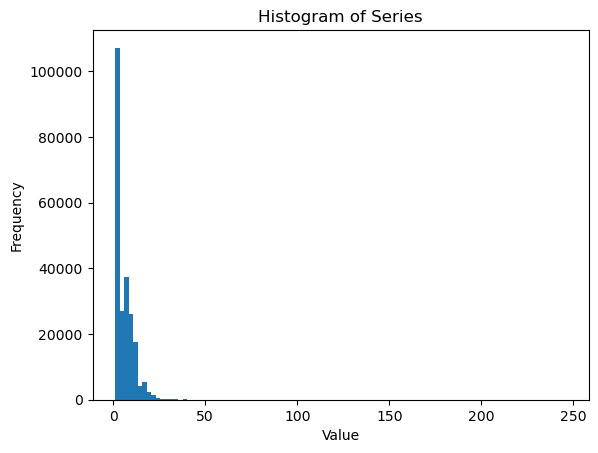

In [81]:
num_acts.plot.hist(bins=100)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Series")
plt.show()

In [99]:
# activity name from the previous row within each session
df = lang_data.loc[~lang_data['Activity Name'].isna(),:]
df["Prev Activity Name"] = df.groupby("Contact Session ID")["Activity Name"].shift(1)

# keep only rows where the current activity is FrontDeskTransfer
out = df.loc[df["Activity Name"].eq("LegalMenu2"),
             ["Contact Session ID", "Activity Start Timestamp", "Prev Activity Name"]]

out['Prev Activity Name'].value_counts()

Prev Activity Name
LegalMenu1                 85621
LegalMenu2                  7497
HousingMenu                 3085
FamilyMenu                  2674
OtherLegalMenu              1984
HIVMenu                      488
BenefitsMenu                 190
EmploymentMenu               144
ImmigrationMenu              107
SeniorsMenu                   67
SeniorsADAPTMenu              20
SeniorsConfirmationMenu        7
Name: count, dtype: int64

In [105]:
lang_data.loc[lang_data['Activity Name'] == 'LegalMenu2','Contact Session ID'].nunique()

85502

In [108]:
85.502-48

37.501999999999995

In [107]:
lang_data_act_nomiss.groupby('Contact Session ID').first()['Activity Name'].value_counts()

Activity Name
LanguageSelectionMenu    229889
Name: count, dtype: int64

In [100]:
out['Prev Activity Name'].value_counts()[1:].sum()

16263

In [102]:
out['Contact Session ID'].nunique()

85502

In [103]:
out

,Contact Session ID,Activity Start Timestamp,Prev Activity Name
41,00014a58-a6ce-4cb2-a529-d55e2c9c304d,2025-02-28 08:35:00,LegalMenu1
88,0002f64b-59d3-4cba-885c-83b997d2fc73,2024-08-28 11:56:53,LegalMenu1
118,000353fe-3aec-4d65-b818-0d2598beb909,2024-05-21 13:35:37,LegalMenu1
119,000353fe-3aec-4d65-b818-0d2598beb909,2024-05-21 13:35:38,LegalMenu2
166,0004f7a4-ea7f-4d4e-9b63-33839fe9653d,2024-07-26 11:56:00,LegalMenu1
...,...,...,...
3328484,fffb7368-31f5-488f-858c-380f67bea0ce,2025-03-25 16:01:13,LegalMenu1
3328515,fffbd8f2-e17e-4635-a4f3-70a2a66eb68e,2025-02-27 13:40:36,LegalMenu1
3328535,fffc8571-cff6-408f-ba73-65435f9cf9d4,2025-07-23 09:32:44,LegalMenu1
3328539,fffc8571-cff6-408f-ba73-65435f9cf9d4,2025-07-23 09:34:06,FamilyMenu


In [ ]:
df_main

In [119]:
df_main_non_missing_activity_names = df_main.loc[~df_main['Activity Name'].isna(),:]
last_activity = df_main_non_missing_activity_names.groupby('Contact Session ID').tail(1)
voicemail = last_activity.loc[last_activity['Activity Name'] == 'ClinicVoicemailTransfer',:]
voicemail['EP Name'].value_counts()

EP Name
Main Number Telephony EP                   12950
Closed Queue Menu Telephony EP              7894
Other Legal Menu Telephony EP               2345
Closed Hours-Holidays Menu Telephony EP     1329
Legal Housing Menu Telephony EP              776
Legal Family Menu Telephony EP               427
Name: count, dtype: int64

In [118]:
familymenu_rows = df_main.loc[df_main['Activity Name'] == 'FamilyMenu',:]
familymenu_data = df_main.loc[df_main['Contact Session ID'].isin(familymenu_rows['Contact Session ID']),:]
family_voice = familymenu_data.loc[familymenu_data['Activity Name'] == 'ClinicVoicemailTransfer',:]
custdata(family_voice['Contact Session ID'].unique()[1])

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour
429,000a9e4a-e954-444e-b716-883ff71601f5,Main Number Telephony EP,NaN,NaN,2025-06-26 15:52:20,NaN,NaN,NaN,15
430,000a9e4a-e954-444e-b716-883ff71601f5,NaN,LACMain,NaN,2025-06-26 15:52:20,NaN,NaN,NaN,15
431,000a9e4a-e954-444e-b716-883ff71601f5,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-06-26 15:52:20,NaN,NaN,NaN,15
432,000a9e4a-e954-444e-b716-883ff71601f5,Main Number Telephony EP,LACMain,NaN,2025-06-26 15:52:20,NaN,NaN,NaN,15
433,000a9e4a-e954-444e-b716-883ff71601f5,Main Number Telephony EP,NaN,MainMenu,2025-06-26 15:52:33,NaN,NaN,NaN,15
434,000a9e4a-e954-444e-b716-883ff71601f5,NaN,PreLegalMenuSeniorsMenu,NaN,2025-06-26 15:52:57,NaN,NaN,NaN,15
435,000a9e4a-e954-444e-b716-883ff71601f5,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SeniorsMenu,2025-06-26 15:52:57,NaN,NaN,NaN,15
436,000a9e4a-e954-444e-b716-883ff71601f5,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SeniorsConfirmationMenu,2025-06-26 15:53:04,NaN,NaN,NaN,15
437,000a9e4a-e954-444e-b716-883ff71601f5,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SuburbsOrCityMenu,2025-06-26 15:53:21,NaN,NaN,NaN,15
438,000a9e4a-e954-444e-b716-883ff71601f5,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SeniorsADAPTMenu,2025-06-26 15:53:44,NaN,NaN,NaN,15


In [121]:
df["Next Activity Name"] = df.groupby("Contact Session ID")["Activity Name"].shift(-1)

# Filter only the rows where the current activity is SimpleDivorceMenu
out = df.loc[df["Activity Name"].eq("SimpleDivorceMenu"),
             ["Contact Session ID", "Activity Start Timestamp", "Next Activity Name"]]

out['Next Activity Name'].value_counts()

Next Activity Name
DivorceOrParentingMenu       915
ClosedQueueMenu              692
ClinicVoicemailTransfer      410
GetLoggedInFamilyAgents       87
GetLoggedInFamilySPAgents     23
Name: count, dtype: int64